# K_Scratch 분류 — Steel Plates Faults (긴 스트레치성 결함)

**목표**: 철강판 표면 결함 측정값으로 **K_Scatch**(긴 스트레치성 결함) 여부를 이진 분류합니다.

**데이터**: `dataset/day2_miniproject_cls.csv` (Steel Plates Faults, 1,941건)

| 구분 | 변수 |
|:---:|:---|
| 위치·크기 | X/Y_Minimum, X/Y_Maximum, Pixels_Areas, X/Y_Perimeter |
| 광도 | Sum/Minimum/Maximum_of_Luminosity, Luminosity_Index |
| 형태 지수 | Edges_Index, Square_Index, Orientation_Index 등 |
| 소재 | TypeOfSteel_A300/A400, Steel_Plate_Thickness, Length_of_Conveyer |
| **타겟** | **K_Scatch** (1=긴 스트레치 결함, 0=해당 없음) |

**분석 흐름**
1. 데이터 탐색 및 전처리
2. 로지스틱 회귀 / 의사결정나무 기본 학습
3. GridSearchCV 하이퍼파라미터 최적화
4. 테스트 예측 및 성능 비교·해석

## 0) 분석 준비

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

# ===== 한글 폰트 설정 =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None

rcParams["axes.unicode_minus"] = False

TARGET = "K_Scatch"
FAULT_COLS = [
    "Pastry", "Z_Scratch", "K_Scatch", "Stains",
    "Dirtiness", "Bumps", "Other_Faults",
]
RANDOM_STATE = 0
TEST_SIZE = 0.3


def set_kr_title(ax, title):
    if KOREAN_FONT:
        ax.set_title(title, fontproperties=KOREAN_FONT)
    else:
        ax.set_title(title)


def get_classscore(real, pred, proba=None, label=""):
    metrics = {
        "Accuracy": accuracy_score(real, pred),
        "Precision": precision_score(real, pred, zero_division=0),
        "Recall": recall_score(real, pred, zero_division=0),
        "F1-score": f1_score(real, pred, zero_division=0),
    }
    if proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(real, proba)

    print(f"[{label}]")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.3f}")
    print("  혼동행렬:")
    print(confusion_matrix(real, pred))
    return metrics


print("한글 폰트:", KOREAN_FONT.get_name() if KOREAN_FONT else "없음")

한글 폰트: Apple SD Gothic Neo


## 1) 데이터 불러오기

In [2]:
DATA_PATH = os.path.join(os.getcwd(), "dataset", "day2_miniproject_cls.csv")
SP_Data = pd.read_csv(DATA_PATH)

print("데이터 크기:", SP_Data.shape)
SP_Data.head()

데이터 크기: (1941, 34)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


---
## 2) 데이터 탐색 (EDA)

### 2-1) 구조적 정보

In [3]:
SP_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [4]:
print("결측치 합계:", SP_Data.isnull().sum().sum())
print("\n결함 유형별 건수:")
print(SP_Data[FAULT_COLS].sum().sort_values(ascending=False))

결측치 합계: 0

결함 유형별 건수:
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
dtype: int64


- 각 행은 **하나의 결함 유형**만 라벨링되어 있습니다 (다중 라벨 없음).
- 따라서 `K_Scatch`는 이미 0/1 이진 타겟으로 사용 가능하며, **다른 결함 유형 컬럼은 입력에서 제외**해야 데이터 누수(leakage)를 방지할 수 있습니다.

### 2-2) 통계적 정보

In [5]:
SP_Data.describe().T

,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869099e+01,37.0000,124.0000,1.270000e+02,1.400000e+02,2.530000e+02


### 2-3) 타겟 클래스 분포

K_Scatch=0 (아님)        1550
K_Scatch=1 (긴 스트레치)     391
Name: K_Scatch, dtype: int64

비율(0)    0.7986
비율(1)    0.2014
Name: K_Scatch, dtype: float64


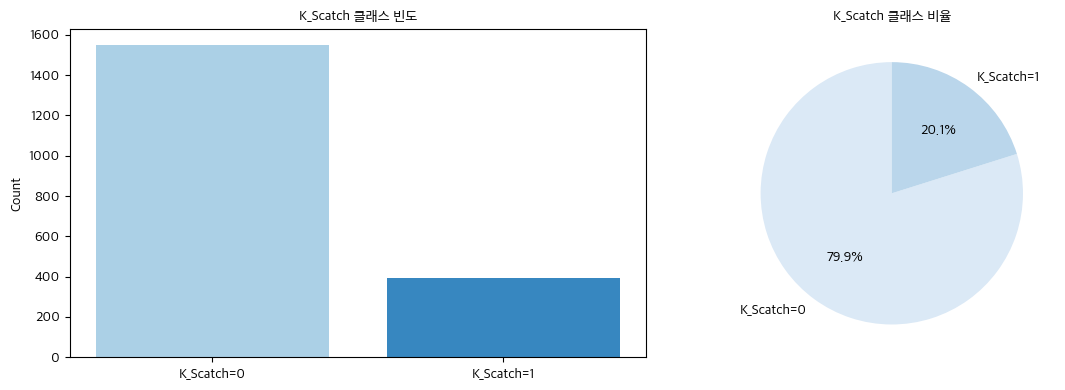

In [6]:
target_counts = SP_Data[TARGET].value_counts().sort_index()
target_ratio = SP_Data[TARGET].value_counts(normalize=True).sort_index()

print(target_counts.rename({0: "K_Scatch=0 (아님)", 1: "K_Scatch=1 (긴 스트레치)"}))
print()
print(target_ratio.round(4).rename({0: "비율(0)", 1: "비율(1)"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["K_Scatch=0", "K_Scatch=1"]

axes[0].bar(labels, target_counts.values, color=sns.color_palette("Blues", 2))
set_kr_title(axes[0], "K_Scatch 클래스 빈도")
axes[0].set_ylabel("Count")

axes[1].pie(target_counts.values, labels=labels, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Blues"))
set_kr_title(axes[1], "K_Scatch 클래스 비율")

plt.tight_layout()
plt.show()

- K_Scatch=1 비율이 상대적으로 낮아 **Accuracy만으로는 모델을 평가하기 어렵습니다**.
- **F1-score, Recall, ROC-AUC**를 함께 확인합니다.

### 2-4) 상관관계 히트맵 (수치형 변수)

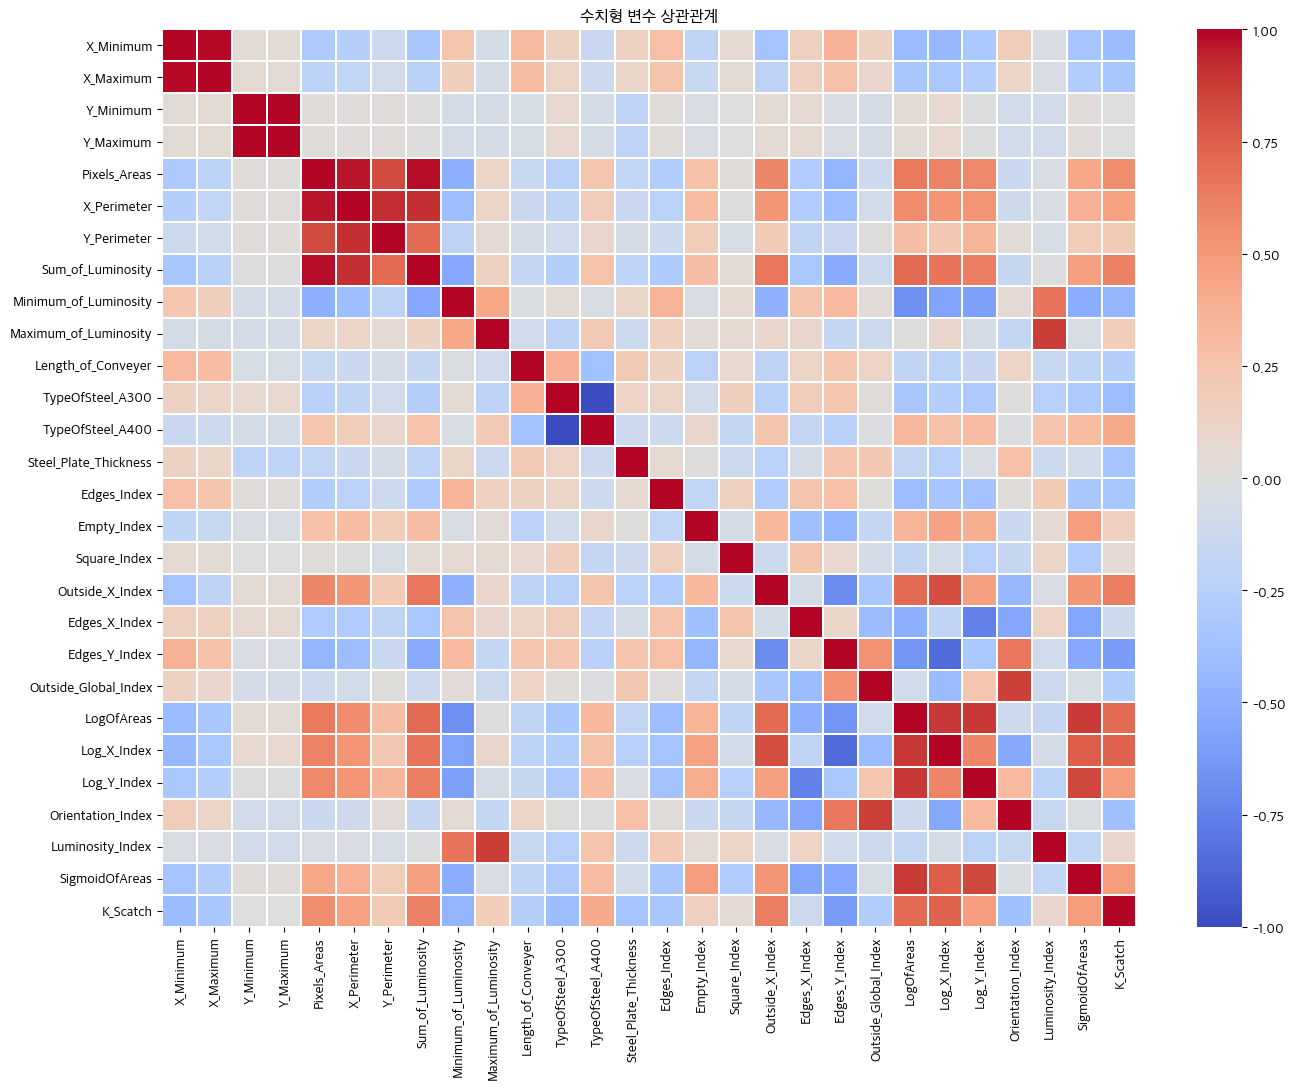

K_Scatch와 상관이 높은 변수 Top 8:
Log_X_Index          0.735860
LogOfAreas           0.704531
Outside_X_Index      0.631370
Sum_of_Luminosity    0.616950
Edges_Y_Index        0.614341
Pixels_Areas         0.556846
SigmoidOfAreas       0.488878
Log_Y_Index          0.481853
Name: K_Scatch, dtype: float64


In [7]:
feature_cols = [c for c in SP_Data.columns if c not in FAULT_COLS]
corr = SP_Data[feature_cols + [TARGET]].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("수치형 변수 상관관계")
plt.tight_layout()
plt.show()

print("K_Scatch와 상관이 높은 변수 Top 8:")
print(
    corr[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .head(8)
)

In [ ]:
# Raw 데이터: 결함 유형별 row 수 확인 (Pastry ~ Other_Faults)
fault_row_counts = SP_Data[FAULT_COLS].sum().sort_values(ascending=False)
fault_row_ratio = (fault_row_counts / len(SP_Data) * 100).round(2)

fault_summary = pd.DataFrame({
    "결함 유형": fault_row_counts.index,
    "row 수": fault_row_counts.values.astype(int),
    "비율(%)": fault_row_ratio.values,
})

print("=== 결함 유형별 row 수 (Raw 데이터) ===")
display(fault_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fault_row_counts.index, fault_row_counts.values, color="steelblue")
set_kr_title(ax, "결함 유형별 row 수")
ax.set_ylabel("Count")
ax.set_xlabel("결함 유형")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"전체 row 수: {len(SP_Data):,}")
print("행당 결함 유형 개수 분포:", SP_Data[FAULT_COLS].sum(axis=1).value_counts().sort_index().to_dict())

---
## 3) 데이터 전처리

### 3-1) 입·출력 변수 분리

로지스틱 회귀 실습(`머신러닝 Day 2-2`)과 동일하게:
- **Y**: `K_Scatch` (이미 0/1)
- **X**: 결함 라벨 7개 컬럼을 제외한 측정·형태 변수
- `TypeOfSteel_A300/A400` 등 범주형은 `get_dummies`로 처리

In [8]:
Y = SP_Data[TARGET]
X = SP_Data.drop(columns=FAULT_COLS)

X = pd.get_dummies(X)
feature_names = X.columns.tolist()

print("입력 변수 수:", X.shape[1])
print("타겟 분포:\n", Y.value_counts())
X.head()

입력 변수 수: 27
타겟 분포:
 0    1550
1     391
Name: K_Scatch, dtype: int64


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000


### 3-2) 학습/테스트 분할 (stratify)

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y,
)

print("전체 데이터 크기   :", X.shape)
print("학습 데이터 크기   :", X_train.shape)
print("테스트 데이터 크기 :", X_test.shape)
print("학습 세트 K_Scatch=1 비율:", round(Y_train.mean(), 4))

전체 데이터 크기   : (1941, 27)
학습 데이터 크기   : (1358, 27)
테스트 데이터 크기 : (583, 27)
학습 세트 K_Scatch=1 비율: 0.2018


### 3-3) 스케일링 (로지스틱 회귀용 MinMaxScaler)

In [10]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("스케일링 완료 — 학습:", X_train_scaled.shape, "/ 테스트:", X_test_scaled.shape)

스케일링 완료 — 학습: (1358, 27) / 테스트: (583, 27)


---
## 4) 기본 모델 학습 및 성능 평가

### 4-1) 로지스틱 회귀 (기본)

In [11]:
LR_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
LR_base.fit(X_train_scaled, Y_train)

LR_base_pred = LR_base.predict(X_test_scaled)
LR_base_proba = LR_base.predict_proba(X_test_scaled)[:, 1]

lr_base_metrics = get_classscore(Y_test, LR_base_pred, LR_base_proba, label="로지스틱 회귀 (기본)")

[로지스틱 회귀 (기본)]
  Accuracy  : 0.957
  Precision : 0.960
  Recall    : 0.821
  F1-score  : 0.885
  ROC-AUC   : 0.984
  혼동행렬:
[[462   4]
 [ 21  96]]


### 4-2) 의사결정나무 (기본)

In [12]:
DT_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
DT_base.fit(X_train, Y_train)

DT_base_pred = DT_base.predict(X_test)
dt_base_metrics = get_classscore(Y_test, DT_base_pred, label="의사결정나무 (기본)")

[의사결정나무 (기본)]
  Accuracy  : 0.964
  Precision : 0.929
  Recall    : 0.889
  F1-score  : 0.908
  혼동행렬:
[[458   8]
 [ 13 104]]


---
## 5) 하이퍼파라미터 최적화 (GridSearchCV)

클래스 불균형을 고려해 **F1-score**를 기준으로 5-Fold CV 탐색합니다.

### 5-1) 로지스틱 회귀 — C, class_weight 탐색

In [13]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_grid=lr_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
lr_grid.fit(X_train_scaled, Y_train)

LR_model = lr_grid.best_estimator_
print("최적 하이퍼파라미터:", lr_grid.best_params_)
print(f"CV 최고 F1-score: {lr_grid.best_score_:.3f}")

LR_pred = LR_model.predict(X_test_scaled)
LR_proba = LR_model.predict_proba(X_test_scaled)[:, 1]
lr_metrics = get_classscore(Y_test, LR_pred, LR_proba, label="로지스틱 회귀 (최적화)")

최적 하이퍼파라미터: {'C': 10, 'class_weight': None}
CV 최고 F1-score: 0.933
[로지스틱 회귀 (최적화)]
  Accuracy  : 0.964
  Precision : 0.929
  Recall    : 0.889
  F1-score  : 0.908
  ROC-AUC   : 0.988
  혼동행렬:
[[458   8]
 [ 13 104]]


### 5-2) 의사결정나무 — max_depth, min_samples_leaf, class_weight 탐색

In [14]:
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "class_weight": [None, "balanced"],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=dt_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
dt_grid.fit(X_train, Y_train)

DT_model = dt_grid.best_estimator_
print("최적 하이퍼파라미터:", dt_grid.best_params_)
print(f"CV 최고 F1-score: {dt_grid.best_score_:.3f}")

DT_pred = DT_model.predict(X_test)
dt_metrics = get_classscore(Y_test, DT_pred, label="의사결정나무 (최적화)")

최적 하이퍼파라미터: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1}
CV 최고 F1-score: 0.947
[의사결정나무 (최적화)]
  Accuracy  : 0.964
  Precision : 0.944
  Recall    : 0.872
  F1-score  : 0.907
  혼동행렬:
[[460   6]
 [ 15 102]]


### 5-3) 의사결정나무 — 사후 가지치기 (ccp_alpha)

Day 2-3 의사결정나무 실습과 같이 `ccp_alpha`별 테스트 F1을 비교해 과적합을 완화합니다.

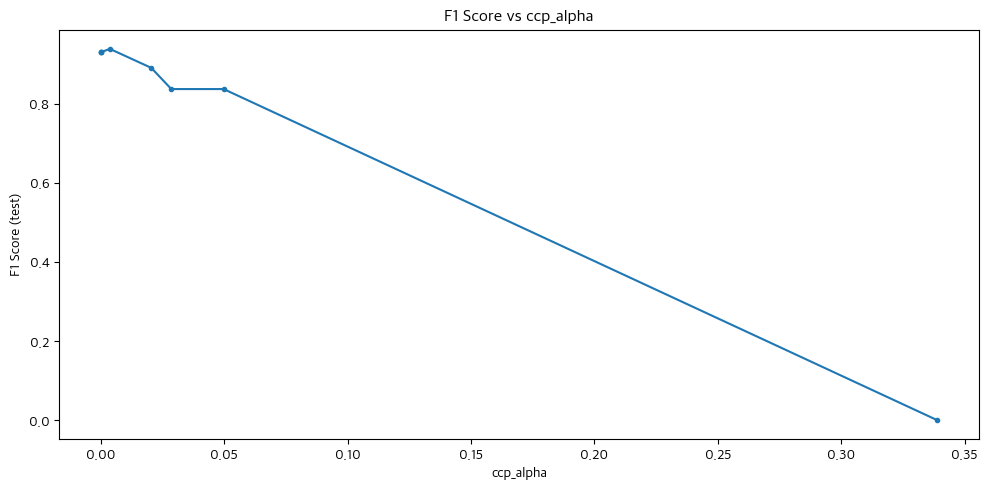

최적 ccp_alpha: 0.003658 (test F1=0.939)
[의사결정나무 (ccp 가지치기)]
  Accuracy  : 0.974
  Precision : 0.898
  Recall    : 0.983
  F1-score  : 0.939
  혼동행렬:
[[453  13]
 [  2 115]]


In [15]:
base_dt = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    **{k: v for k, v in dt_grid.best_params_.items() if k != "class_weight"},
    class_weight=dt_grid.best_params_.get("class_weight"),
)
path = base_dt.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas

f1_scores = []
for alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=RANDOM_STATE,
        class_weight=dt_grid.best_params_.get("class_weight"),
    )
    dt_pruned.fit(X_train, Y_train)
    pred = dt_pruned.predict(X_test)
    f1_scores.append(f1_score(Y_test, pred, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, f1_scores, marker="o", markersize=3)
plt.xlabel("ccp_alpha")
plt.ylabel("F1 Score (test)")
plt.title("F1 Score vs ccp_alpha")
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(f1_scores))
best_ccp_alpha = ccp_alphas[best_idx]
print(f"최적 ccp_alpha: {best_ccp_alpha:.6f} (test F1={f1_scores[best_idx]:.3f})")

DT_pruned = DecisionTreeClassifier(
    ccp_alpha=best_ccp_alpha,
    random_state=RANDOM_STATE,
    class_weight=dt_grid.best_params_.get("class_weight"),
)
DT_pruned.fit(X_train, Y_train)
DT_pruned_pred = DT_pruned.predict(X_test)
dt_pruned_metrics = get_classscore(Y_test, DT_pruned_pred, label="의사결정나무 (ccp 가지치기)")

---
## 6) 결과 및 성능 정리

In [16]:
results = pd.DataFrame([
    {"Model": "Logistic Regression (기본)", **lr_base_metrics},
    {"Model": f"Logistic Regression (최적: {lr_grid.best_params_})", **lr_metrics},
    {"Model": "Decision Tree (기본)", **dt_base_metrics},
    {"Model": f"Decision Tree (최적: {dt_grid.best_params_})", **dt_metrics},
    {"Model": f"Decision Tree (ccp={best_ccp_alpha:.4f})", **dt_pruned_metrics},
]).round(3)

results.sort_values("F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Decision Tree (ccp=0.0037),0.974,0.898,0.983,0.939,NaN
1,"Logistic Regression (최적: {'C': 10, 'class_weig...",0.964,0.929,0.889,0.908,0.988
2,Decision Tree (기본),0.964,0.929,0.889,0.908,NaN
3,Decision Tree (최적: {'class_weight': 'balanced'...,0.964,0.944,0.872,0.907,NaN
0,Logistic Regression (기본),0.957,0.960,0.821,0.885,0.984


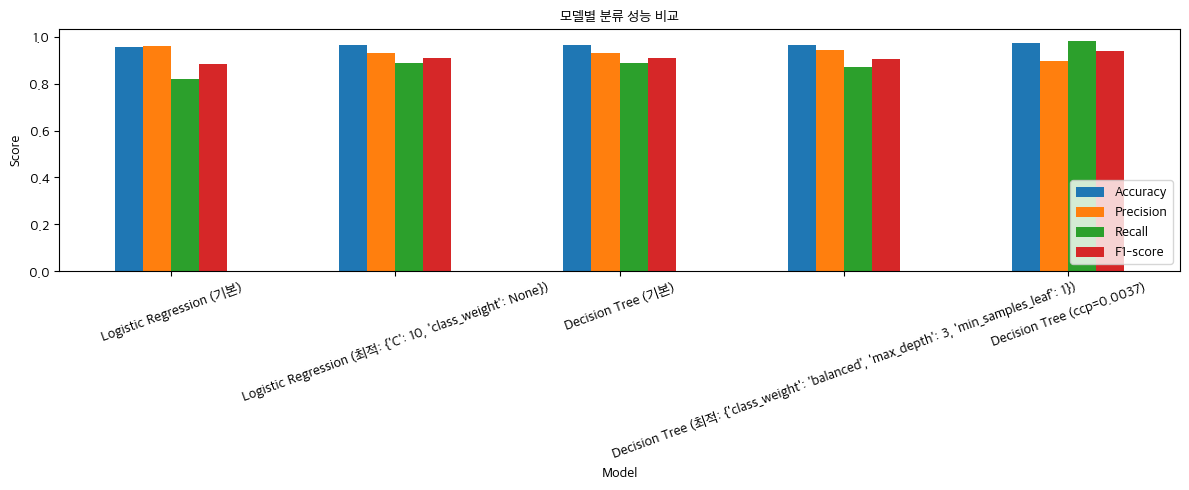

In [17]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score"]
plot_df = results.set_index("Model")[metric_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=20)
set_kr_title(ax, "모델별 분류 성능 비교")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6-1) 테스트 세트 예측 결과 (최적 모델)

In [18]:
# F1 기준 최고 모델 선택
best_idx = results["F1-score"].idxmax()
best_row = results.loc[best_idx]
print("최종 선택 모델:", best_row["Model"])
print("F1-score:", best_row["F1-score"])

model_outputs = {
    "Logistic Regression (기본)": (LR_base_pred, LR_base_proba),
    f"Logistic Regression (최적: {lr_grid.best_params_})": (LR_pred, LR_proba),
    "Decision Tree (기본)": (DT_base_pred, None),
    f"Decision Tree (최적: {dt_grid.best_params_})": (DT_pred, None),
    f"Decision Tree (ccp={best_ccp_alpha:.4f})": (DT_pruned_pred, None),
}
final_name = best_row["Model"]
final_pred, final_proba = model_outputs[final_name]

pred_df = X_test.copy()
pred_df["actual"] = Y_test.values
pred_df["predicted"] = final_pred
if final_proba is not None:
    pred_df["prob_K_Scatch"] = final_proba

print(f"\n[{final_name}] classification report:")
print(classification_report(Y_test, final_pred, target_names=["K_Scatch=0", "K_Scatch=1"]))

pred_df[["actual", "predicted"] + (["prob_K_Scatch"] if final_proba is not None else [])].head(10)

최종 선택 모델: Decision Tree (ccp=0.0037)
F1-score: 0.939

[Decision Tree (ccp=0.0037)] classification report:
              precision    recall  f1-score   support

  K_Scatch=0       1.00      0.97      0.98       466
  K_Scatch=1       0.90      0.98      0.94       117

    accuracy                           0.97       583
   macro avg       0.95      0.98      0.96       583
weighted avg       0.98      0.97      0.97       583



,actual,predicted
290,0,0
1347,0,0
991,0,0
761,0,0
1428,0,0
1240,0,0
1535,0,0
1342,0,0
810,0,0
1802,0,0


### 6-2) 모델 해석

[로지스틱 회귀] |계수| Top 10
Steel_Plate_Thickness   -8.877
Empty_Index             -6.899
Luminosity_Index         6.207
Pixels_Areas             5.262
LogOfAreas               4.531
Log_Y_Index              4.411
Maximum_of_Luminosity    4.227
Orientation_Index       -3.740
Square_Index             3.468
TypeOfSteel_A400         3.139
dtype: float64


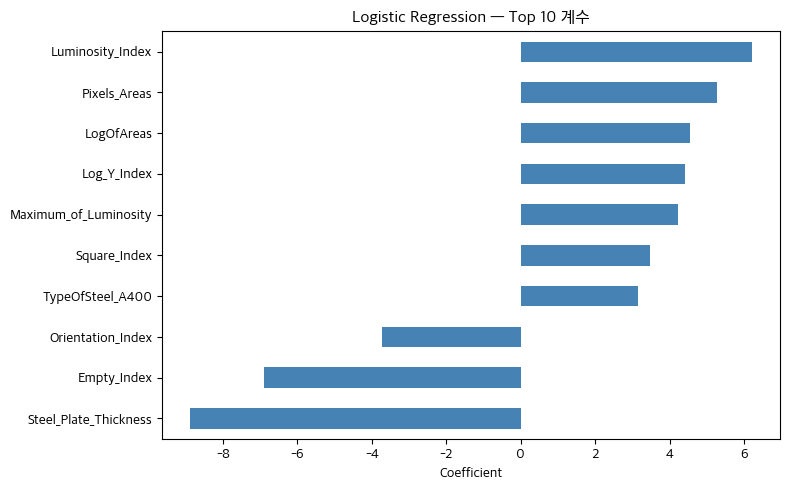

In [19]:
# 로지스틱 회귀 계수 (절대값 Top 10)
lr_coef = pd.Series(LR_model.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)
print("[로지스틱 회귀] |계수| Top 10")
print(lr_coef.head(10).round(3))

plt.figure(figsize=(8, 5))
lr_coef.head(10).sort_values().plot(kind="barh", color="steelblue")
plt.title("Logistic Regression — Top 10 계수")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

[의사결정나무] 변수 중요도 Top 10
Outside_X_Index          0.7680
Steel_Plate_Thickness    0.1127
Maximum_of_Luminosity    0.0647
X_Minimum                0.0463
TypeOfSteel_A400         0.0083
Pixels_Areas             0.0000
Square_Index             0.0000
Luminosity_Index         0.0000
Orientation_Index        0.0000
Log_Y_Index              0.0000
dtype: float64


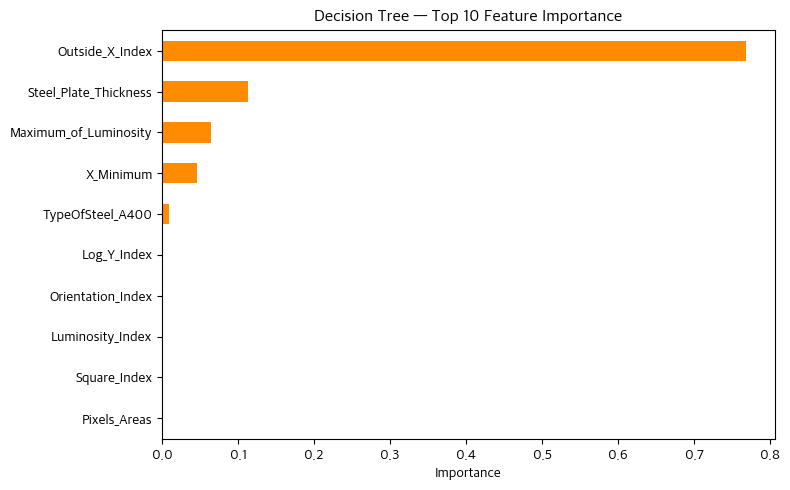

In [20]:
# 의사결정나무 변수 중요도 Top 10
dt_importance = pd.Series(DT_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("[의사결정나무] 변수 중요도 Top 10")
print(dt_importance.head(10).round(4))

plt.figure(figsize=(8, 5))
dt_importance.head(10).sort_values().plot(kind="barh", color="darkorange")
plt.title("Decision Tree — Top 10 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

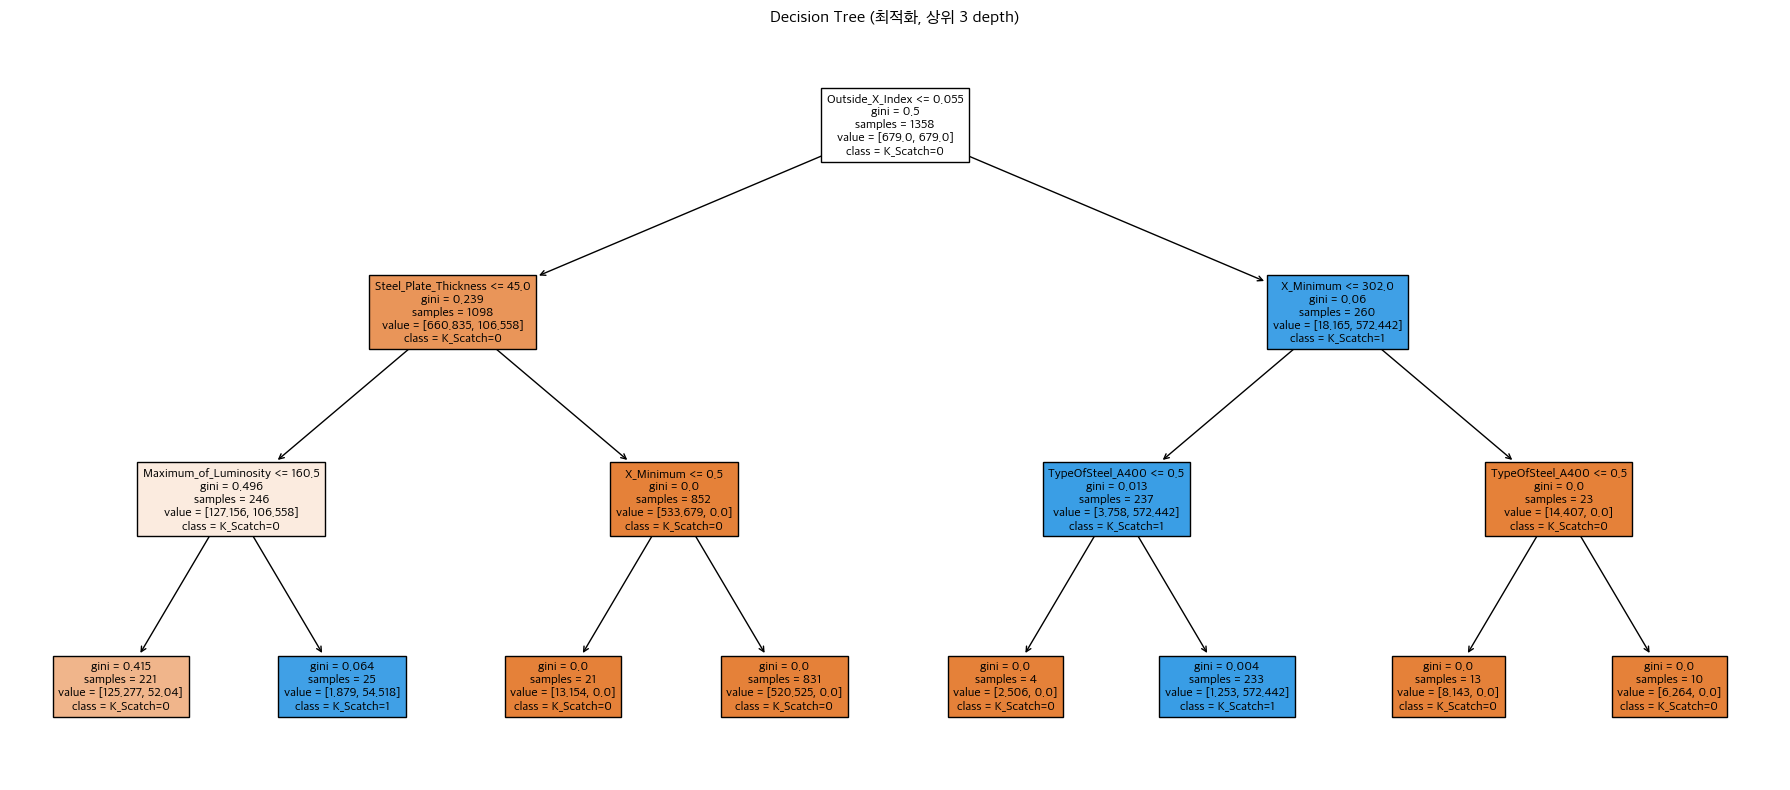

In [21]:
# 최적 의사결정나무 구조 시각화 (깊이 제한)
plt.figure(figsize=(18, 8))
tree.plot_tree(
    DT_model,
    class_names=["K_Scatch=0", "K_Scatch=1"],
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    max_depth=3,
)
plt.title("Decision Tree (최적화, 상위 3 depth)")
plt.tight_layout()
plt.show()

### 6-3) 어떤 성능 지표를 기준으로 모델을 판단해야 할까?

`F1-score`는 **Precision**과 **Recall**의 균형을 함께 반영하므로, 이처럼 한쪽 클래스(`K_Scatch=1`)가 상대적으로 적은 분류 문제에서 매우 유용합니다.

하지만 **F1 하나만으로 모델을 단정하는 것은 부족**할 수 있습니다.

- `Accuracy`: 전체적으로 얼마나 많이 맞췄는지 보여주지만, 클래스 불균형이 있으면 과대평가될 수 있음
- `Precision`: 결함이라고 예측한 것 중 실제 결함 비율. 오탐(False Positive)을 줄이고 싶을 때 중요
- `Recall`: 실제 결함을 얼마나 놓치지 않았는지. 미탐(False Negative)이 치명적일 때 중요
- `F1-score`: Precision과 Recall의 균형값. 불균형 분류에서 대표 지표
- `ROC-AUC`: 임계값 전반에서 분류 성향을 보는 지표. 확률 기반 모델 비교에 유용

따라서 이 노트북에서는 **최종 모델 선택 기준은 F1-score**로 두되, 해석할 때는 **Accuracy / Precision / Recall / F1 / ROC-AUC**를 함께 확인합니다.

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Decision Tree (ccp=0.0037),0.974,0.898,0.983,0.939,NaN
1,"Logistic Regression (최적: {'C': 10, 'class_weig...",0.964,0.929,0.889,0.908,0.988
2,Decision Tree (기본),0.964,0.929,0.889,0.908,NaN
3,Decision Tree (최적: {'class_weight': 'balanced'...,0.964,0.944,0.872,0.907,NaN
0,Logistic Regression (기본),0.957,0.960,0.821,0.885,0.984


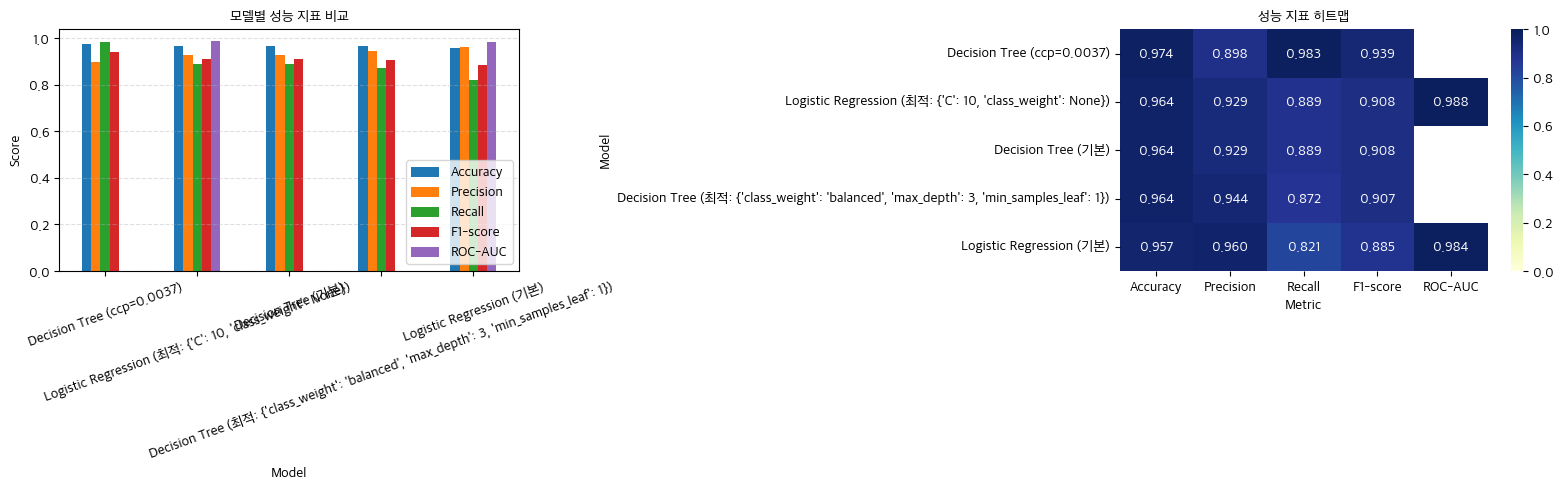

해석 가이드
- 결함을 놓치면 안 되는 문제라면 Recall이 높은 모델을 우선 검토합니다.
- 오탐을 줄이는 것이 중요하면 Precision이 높은 모델을 봅니다.
- 둘의 균형을 가장 무난하게 보려면 F1-score를 기준으로 선택합니다.
- ROC-AUC는 확률 기반 분류 성향 비교에 유용하며, 로지스틱 회귀에서 특히 해석 가치가 있습니다.


In [22]:
compare_cols = [col for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"] if col in results.columns]
compare_df = results[["Model"] + compare_cols].copy()
compare_df = compare_df.sort_values("F1-score", ascending=False)

display(compare_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 막대그래프: 모델별 핵심 성능지표 비교
plot_df = compare_df.set_index("Model")
plot_df.plot(kind="bar", ax=axes[0], rot=20)
set_kr_title(axes[0], "모델별 성능 지표 비교")
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# 히트맵: 지표별 상대 비교를 한눈에 확인
sns.heatmap(
    plot_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    ax=axes[1],
)
set_kr_title(axes[1], "성능 지표 히트맵")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()

print("해석 가이드")
print("- 결함을 놓치면 안 되는 문제라면 Recall이 높은 모델을 우선 검토합니다.")
print("- 오탐을 줄이는 것이 중요하면 Precision이 높은 모델을 봅니다.")
print("- 둘의 균형을 가장 무난하게 보려면 F1-score를 기준으로 선택합니다.")
print("- ROC-AUC는 확률 기반 분류 성향 비교에 유용하며, 로지스틱 회귀에서 특히 해석 가치가 있습니다.")

---
## 7) 요약

| 항목 | 내용 |
|:---:|:---|
| 데이터 | Steel Plates Faults 1,941건, 결함 유형당 1행 |
| 타겟 | `K_Scatch` (긴 스트레치성 결함 0/1) |
| 전처리 | 결함 라벨 7개 제외 → `get_dummies` → stratify 분할 → LR용 MinMaxScaler |
| 모델 | 로지스틱 회귀, 의사결정나무 (+ GridSearchCV, ccp 가지치기) |
| 평가 지표 | Accuracy, Precision, Recall, F1, ROC-AUC(로지스틱) |

**해석 포인트**
- `Outside_X_Index`, `Steel_Plate_Thickness`, `Pixels_Areas` 등 형태·크기 변수가 K_Scatch 분류에 중요한 경향을 보입니다.
- 클래스 불균형이 있으므로 **F1/Recall**을 기준으로 최적 모델을 선택하는 것이 적절합니다.